# Import paths and libraries

In [22]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path

from sklearn.svm import SVC

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize


# ============================================================
# PATH CONFIGURATION
# ============================================================

FEATURE_DIR = Path(
    r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Features(1)"
)

PCA_TRAIN_FILE = (
    FEATURE_DIR / "pca_train.csv"
)

PCA_TEST_FILE = (
    FEATURE_DIR / "pca_test.csv"
)


# ============================================================
# MODEL OUTPUT DIRECTORY
# ============================================================

MODEL_DIR = Path(
    r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 70)
print("SVM + PCA CLASSIFICATION")
print("=" * 70)

print("\nPCA Train file:")
print(PCA_TRAIN_FILE)

print("\nPCA Test file:")
print(PCA_TEST_FILE)

print("\nModel directory:")
print(MODEL_DIR)

SVM + PCA CLASSIFICATION

PCA Train file:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Features(1)\pca_train.csv

PCA Test file:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Features(1)\pca_test.csv

Model directory:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS


# Load pca 

In [23]:

print("=" * 70)
print("LOADING PCA DATA")
print("=" * 70)


# ------------------------------------------------------------
# Load CSV files
# ------------------------------------------------------------

train_df = pd.read_csv(
    PCA_TRAIN_FILE
)

test_df = pd.read_csv(
    PCA_TEST_FILE
)


# ------------------------------------------------------------
# Display shapes
# ------------------------------------------------------------

print(
    "\nTrain shape:",
    train_df.shape
)

print(
    "Test shape :",
    test_df.shape
)


# ------------------------------------------------------------
# Check class column
# ------------------------------------------------------------

if "class" not in train_df.columns:
    raise ValueError(
        "'class' column not found in training CSV."
    )

if "class" not in test_df.columns:
    raise ValueError(
        "'class' column not found in testing CSV."
    )


# ------------------------------------------------------------
# Separate labels
# ------------------------------------------------------------

y_train = train_df["class"].astype(str)

y_test = test_df["class"].astype(str)


# ------------------------------------------------------------
# Extract numeric PCA features
# ------------------------------------------------------------

X_train = (
    train_df
    .drop(columns=["class"])
    .select_dtypes(include=[np.number])
)

X_test = (
    test_df
    .drop(columns=["class"])
    .select_dtypes(include=[np.number])
)


# ------------------------------------------------------------
# Remove accidental index columns
# ------------------------------------------------------------

X_train = X_train.loc[
    :,
    ~X_train.columns.str.startswith("Unnamed")
]

X_test = X_test.loc[
    :,
    ~X_test.columns.str.startswith("Unnamed")
]


# ------------------------------------------------------------
# Convert to float32
# ------------------------------------------------------------

X_train = X_train.astype(
    np.float32
)

X_test = X_test.astype(
    np.float32
)


# ============================================================
# DISPLAY INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("FEATURE INFORMATION")
print("=" * 70)

print(
    "\nNumber of PCA features:",
    X_train.shape[1]
)

print(
    "Training samples:",
    X_train.shape[0]
)

print(
    "Testing samples :",
    X_test.shape[0]
)


print("\nPCA feature columns:")

print(
    X_train.columns.tolist()
)


# ============================================================
# CHECK TRAIN / TEST FEATURE MATCH
# ============================================================

if list(X_train.columns) != list(X_test.columns):

    raise ValueError(
        "Train and test PCA feature columns do not match."
    )


# ============================================================
# CHECK NaN / INFINITE VALUES
# ============================================================

if not np.isfinite(
    X_train.to_numpy()
).all():

    raise ValueError(
        "NaN or infinite values found in training data."
    )


if not np.isfinite(
    X_test.to_numpy()
).all():

    raise ValueError(
        "NaN or infinite values found in testing data."
    )


print("\nNo NaN or infinite values found.")


# ============================================================
# CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("TRAIN CLASS DISTRIBUTION")
print("=" * 70)

print(
    y_train.value_counts()
)


print("\n" + "=" * 70)
print("TEST CLASS DISTRIBUTION")
print("=" * 70)

print(
    y_test.value_counts()
)

LOADING PCA DATA

Train shape: (3883, 52)
Test shape : (830, 52)

FEATURE INFORMATION

Number of PCA features: 50
Training samples: 3883
Testing samples : 830

PCA feature columns:
['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'PC27', 'PC28', 'PC29', 'PC30', 'PC31', 'PC32', 'PC33', 'PC34', 'PC35', 'PC36', 'PC37', 'PC38', 'PC39', 'PC40', 'PC41', 'PC42', 'PC43', 'PC44', 'PC45', 'PC46', 'PC47', 'PC48', 'PC49', 'PC50']

No NaN or infinite values found.

TRAIN CLASS DISTRIBUTION
class
pituitary     1455
meningioma    1320
glioma        1108
Name: count, dtype: int64

TEST CLASS DISTRIBUTION
class
meningioma    301
pituitary     295
glioma        234
Name: count, dtype: int64


# svm hypermeter TUning

In [24]:

# ============================================================
# CELL 3: FAST SVM HYPERPARAMETER TUNING
# ============================================================
#
# Purpose:
#     Find the best SVM hyperparameters using ONLY:
#
#         X_train
#         y_train
#
# IMPORTANT:
#     X_test and y_test are NOT used in this cell.
#
# The final SVM will be trained in the next cell using the
# best parameters found here.
#
# SPEED OPTIMIZATION:
#     - Small parameter grid
#     - 3-fold Stratified Cross-Validation
#     - probability=False during tuning
#     - n_jobs=-1
#
# Total combinations:
#     Linear SVM = 2
#     RBF SVM    = 2
#
# Total = 4 combinations
#
# With 3-fold CV:
#
#     4 × 3 = 12 model fits
# ============================================================


from sklearn.svm import SVC
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    ParameterGrid
)


print("=" * 70)
print("FAST SVM HYPERPARAMETER TUNING")
print("=" * 70)


# ============================================================
# 1. BASE SVM MODEL
# ============================================================
#
# probability=False:
#
# We do not need probability estimates during hyperparameter
# tuning.
#
# This keeps the GridSearch faster.
#
# probability=True will be enabled later when the final SVM
# is trained.
# ============================================================

svm = SVC(
    probability=False,
    random_state=42
)


# ============================================================
# 2. SMALL PARAMETER GRID
# ============================================================
#
# We test only a few meaningful configurations.
#
# ------------------------------------------------------------
# Linear SVM
# ------------------------------------------------------------
#
# C:
#     1
#     10
#
# ------------------------------------------------------------
# RBF SVM
# ------------------------------------------------------------
#
# C:
#     1
#     10
#
# gamma:
#     scale
#
# ------------------------------------------------------------
#
# class_weight=None is used here to keep the search small.
#
# If your training classes are strongly imbalanced, we can
# include "balanced" later.
# ============================================================

param_grid = [

    # --------------------------------------------------------
    # LINEAR KERNEL
    # --------------------------------------------------------

    {
        "kernel": ["linear"],

        "C": [
            1,
            10
        ]
    },


    # --------------------------------------------------------
    # RBF KERNEL
    # --------------------------------------------------------

    {
        "kernel": ["rbf"],

        "C": [
            1,
            10
        ],

        "gamma": [
            "scale"
        ]
    }
]


# ============================================================
# 3. COUNT PARAMETER COMBINATIONS
# ============================================================

number_of_combinations = len(
    list(
        ParameterGrid(param_grid)
    )
)


print(
    "\nNumber of parameter combinations:",
    number_of_combinations
)


# ============================================================
# 4. STRATIFIED CROSS-VALIDATION
# ============================================================
#
# StratifiedKFold keeps the class distribution approximately
# equal across the folds.
#
# 3 folds are used instead of 5 to reduce training time.
# ============================================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


print(
    "Cross-validation folds:",
    cv.n_splits
)


print(
    "Total model fits:",
    number_of_combinations * cv.n_splits
)


# ============================================================
# 5. GRID SEARCH
# ============================================================
#
# scoring="f1_macro":
#
#     Macro-F1 calculates F1 for each class and then takes
#     their average.
#
#     This prevents a large class from dominating the score.
#
# n_jobs=-1:
#
#     Uses all available CPU cores.
# ============================================================

grid_search = GridSearchCV(

    estimator=svm,

    param_grid=param_grid,

    cv=cv,

    scoring="f1_macro",

    n_jobs=-1,

    verbose=2,

    return_train_score=False,

    refit=False
)


# ============================================================
# 6. DISPLAY TRAINING INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("STARTING SVM HYPERPARAMETER SEARCH")
print("=" * 70)

print(
    "\nTraining samples:",
    X_train.shape[0]
)

print(
    "PCA features:",
    X_train.shape[1]
)

print(
    "\nOnly X_train and y_train are being used."
)

print(
    "X_test and y_test are NOT used."
)


# ============================================================
# 7. RUN GRID SEARCH
# ============================================================

grid_search.fit(
    X_train,
    y_train
)


# ============================================================
# 8. GET BEST PARAMETERS
# ============================================================

best_params = grid_search.best_params_


# ============================================================
# 9. GET BEST CROSS-VALIDATION SCORE
# ============================================================

best_cv_score = grid_search.best_score_


# ============================================================
# 10. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 70)
print("BEST SVM PARAMETERS")
print("=" * 70)

print(
    "\nBest Parameters:"
)

print(
    best_params
)


print(
    "\nBest Cross-Validation Macro-F1:"
)

print(
    f"{best_cv_score * 100:.2f}%"
)


# ============================================================
# 11. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING COMPLETE")
print("=" * 70)

print(
    "\nBest Parameters:",
    best_params
)

print(
    "Best CV Macro-F1:",
    f"{best_cv_score * 100:.2f}%"
)

print(
    "\nThese parameters will be used to train the final SVM"
)

print(
    "in the next cell."
)



FAST SVM HYPERPARAMETER TUNING

Number of parameter combinations: 4
Cross-validation folds: 3
Total model fits: 12

STARTING SVM HYPERPARAMETER SEARCH

Training samples: 3883
PCA features: 50

Only X_train and y_train are being used.
X_test and y_test are NOT used.
Fitting 3 folds for each of 4 candidates, totalling 12 fits

BEST SVM PARAMETERS

Best Parameters:
{'C': 10, 'kernel': 'linear'}

Best Cross-Validation Macro-F1:
81.05%

HYPERPARAMETER TUNING COMPLETE

Best Parameters: {'C': 10, 'kernel': 'linear'}
Best CV Macro-F1: 81.05%

These parameters will be used to train the final SVM
in the next cell.


# train and save svm

In [25]:

# ============================================================
# CELL 4: TRAIN AND SAVE FINAL SVM
# ============================================================
#
# Purpose:
#     Train the final SVM using the best hyperparameters
#     obtained from Cell 3.
#
# IMPORTANT:
#     - Only X_train and y_train are used for training.
#     - X_test and y_test are NOT used here.
#     - probability=True is enabled because the trained model
#       will later be used with predict_proba() for ROC/AUC.
#     - The trained model is saved for the separate testing
#       and evaluation cells.
# ============================================================


print("=" * 70)
print("TRAINING FINAL SVM")
print("=" * 70)


# ============================================================
# 1. BEST PARAMETERS FROM CELL 3
# ============================================================
#
# Cell 3 produced:
#
#     {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
#
# best_params already contains these values.
# ============================================================

print(
    "\nBest SVM parameters:"
)

print(
    best_params
)


# ============================================================
# 2. CREATE FINAL SVM
# ============================================================
#
# probability=True:
#
#     Enables predict_proba() for probability-based evaluation
#     such as ROC curve and AUC.
#
# random_state=42:
#
#     Makes the probability calibration reproducible.
# ============================================================

final_svm = SVC(
    **best_params,
    probability=True,
    random_state=42
)


# ============================================================
# 3. TRAIN FINAL SVM
# ============================================================
#
# The model is now trained on the ENTIRE training dataset.
#
# No test samples are used.
# ============================================================

print("\nTraining final SVM...")

final_svm.fit(
    X_train,
    y_train
)


# ============================================================
# 4. DISPLAY TRAINING INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL SVM TRAINING COMPLETE")
print("=" * 70)

print(
    "\nTraining samples:",
    X_train.shape[0]
)

print(
    "PCA features:",
    X_train.shape[1]
)

print(
    "Kernel:",
    final_svm.kernel
)

print(
    "C:",
    final_svm.C
)

print(
    "Gamma:",
    final_svm.gamma
)

print(
    "Probability enabled:",
    final_svm.probability
)


# ============================================================
# 5. SAVE FINAL SVM MODEL
# ============================================================
#
# The model will be loaded later for testing and evaluation.
# ============================================================

SVM_MODEL_FILE = (
    MODEL_DIR / "final_svm.pkl"
)


joblib.dump(
    final_svm,
    SVM_MODEL_FILE
)


# ============================================================
# 6. VERIFY SAVED MODEL
# ============================================================

print(
    "\nSaved SVM model:"
)

print(
    SVM_MODEL_FILE
)

print(
    "\nFinal SVM model saved successfully."
)


# ============================================================
# 7. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CELL 4 COMPLETE")
print("=" * 70)

print(
    "\nBest parameters:",
    best_params
)

print(
    "Model file:",
    SVM_MODEL_FILE
)

print(
    "\nThe saved model will be used in the next cell"
)

print(
    "for test prediction and probability prediction."
)



TRAINING FINAL SVM

Best SVM parameters:
{'C': 10, 'kernel': 'linear'}

Training final SVM...

FINAL SVM TRAINING COMPLETE

Training samples: 3883
PCA features: 50
Kernel: linear
C: 10
Gamma: scale
Probability enabled: True

Saved SVM model:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\final_svm.pkl

Final SVM model saved successfully.

CELL 4 COMPLETE

Best parameters: {'C': 10, 'kernel': 'linear'}
Model file: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\final_svm.pkl

The saved model will be used in the next cell
for test prediction and probability prediction.


# svm testing 

In [26]:

# ============================================================
# CELL 5: LOAD SAVED SVM + TEST PREDICTION
# ============================================================
#
# Purpose:
#     1. Load the already trained SVM model.
#     2. Use the PCA-transformed test dataset.
#     3. Generate class predictions using predict().
#     4. Generate class probabilities using predict_proba().
#
# IMPORTANT:
#     The SVM was already trained in Cell 4.
#
#     This cell DOES NOT retrain the model.
#
#     X_test and y_test are used ONLY for final testing.
# ============================================================


print("=" * 70)
print("LOADING SAVED SVM AND PREDICTING TEST DATA")
print("=" * 70)


# ============================================================
# 1. LOAD SAVED SVM MODEL
# ============================================================

print(
    "\nLoading saved SVM model..."
)

svm_model = joblib.load(
    SVM_MODEL_FILE
)


print(
    "SVM model loaded successfully."
)

print(
    "\nModel:"
)

print(
    svm_model
)


# ============================================================
# 2. VERIFY TEST DATA
# ============================================================

print("\n" + "=" * 70)
print("TEST DATA")
print("=" * 70)

print(
    "\nTest samples:",
    X_test.shape[0]
)

print(
    "PCA features:",
    X_test.shape[1]
)

print(
    "Classes:",
    svm_model.classes_
)


# ============================================================
# 3. CHECK FEATURE COUNT
# ============================================================
#
# The number of PCA features in the test data must match the
# number of features used when training the SVM.
# ============================================================

if X_test.shape[1] != svm_model.n_features_in_:

    raise ValueError(
        "Test feature count does not match the features "
        "used to train the SVM."
    )


print(
    "\nFeature count verified."
)


# ============================================================
# 4. PREDICT TEST CLASSES
# ============================================================
#
# predict() returns the predicted class label for each
# test sample.
# ============================================================

print("\n" + "=" * 70)
print("GENERATING CLASS PREDICTIONS")
print("=" * 70)

y_pred = svm_model.predict(
    X_test
)


print(
    "\nClass predictions generated."
)

print(
    "Prediction shape:",
    y_pred.shape
)


# ============================================================
# 5. PREDICT TEST PROBABILITIES
# ============================================================
#
# predict_proba() returns the probability of every class
# for every test sample.
#
# Shape:
#
#     (number of test samples, number of classes)
#
# The column order is given by:
#
#     svm_model.classes_
# ============================================================

print("\n" + "=" * 70)
print("GENERATING CLASS PROBABILITIES")
print("=" * 70)

y_proba = svm_model.predict_proba(
    X_test
)


print(
    "\nClass probabilities generated."
)

print(
    "Probability shape:",
    y_proba.shape
)


# ============================================================
# 6. GET PREDICTION CONFIDENCE
# ============================================================
#
# The maximum probability represents the model's confidence
# in its predicted class.
# ============================================================

prediction_confidence = np.max(
    y_proba,
    axis=1
)


# ============================================================
# 7. DISPLAY SAMPLE PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)


print(
    "\nFirst 10 actual labels:"
)

print(
    y_test.iloc[:10].to_numpy()
)


print(
    "\nFirst 10 predicted labels:"
)

print(
    y_pred[:10]
)


print(
    "\nFirst 10 probability predictions:"
)

print(
    y_proba[:10]
)


print(
    "\nFirst 10 prediction confidences:"
)

print(
    prediction_confidence[:10]
)


# ============================================================
# 8. VERIFY PROBABILITY VALUES
# ============================================================
#
# Each row of y_proba should sum approximately to 1.
# ============================================================

probability_sums = np.sum(
    y_proba,
    axis=1
)


if not np.allclose(
    probability_sums,
    1.0
):

    raise ValueError(
        "Invalid probability values detected."
    )


print(
    "\nProbability values verified."
)


# ============================================================
# 9. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("TEST PREDICTION COMPLETE")
print("=" * 70)

print(
    "\nTest samples:",
    len(y_pred)
)

print(
    "Number of classes:",
    len(svm_model.classes_)
)

print(
    "Prediction shape:",
    y_pred.shape
)

print(
    "Probability shape:",
    y_proba.shape
)

print(
    "\nClass order:"
)

print(
    svm_model.classes_
)

print(
    "\n✓ Saved SVM loaded"
)

print(
    "✓ Test predictions generated"
)

print(
    "✓ Test probabilities generated"
)

print(
    "✓ Probability values verified"
)

print(
    "\nReady for evaluation in the next cells."
)



LOADING SAVED SVM AND PREDICTING TEST DATA

Loading saved SVM model...
SVM model loaded successfully.

Model:
SVC(C=10, kernel='linear', probability=True, random_state=42)

TEST DATA

Test samples: 830
PCA features: 50
Classes: ['glioma' 'meningioma' 'pituitary']

Feature count verified.

GENERATING CLASS PREDICTIONS

Class predictions generated.
Prediction shape: (830,)

GENERATING CLASS PROBABILITIES

Class probabilities generated.
Probability shape: (830, 3)

SAMPLE PREDICTIONS

First 10 actual labels:
['glioma' 'glioma' 'glioma' 'glioma' 'glioma' 'glioma' 'glioma' 'glioma'
 'glioma' 'glioma']

First 10 predicted labels:
['glioma' 'glioma' 'glioma' 'glioma' 'glioma' 'glioma' 'glioma' 'glioma'
 'glioma' 'glioma']

First 10 probability predictions:
[[9.96376343e-01 1.38659172e-05 3.60979154e-03]
 [7.34276169e-01 1.43051908e-02 2.51418640e-01]
 [6.83735780e-01 5.71304853e-02 2.59133735e-01]
 [9.98541872e-01 3.57479525e-04 1.10064844e-03]
 [8.85444724e-01 5.38576627e-02 6.06976137e-02]


# svm evaluation 

In [27]:

# ============================================================
# CELL 6: CLASSIFICATION EVALUATION
# ============================================================
#
# Purpose:
#     Evaluate the final SVM on the unseen test dataset.
#
# Metrics:
#     - Accuracy
#     - Precision
#     - Recall
#     - F1-score
#     - Classification Report
#
# IMPORTANT:
#     The model is NOT retrained in this cell.
#
#     y_pred was generated in Cell 5 using the saved SVM.
#     y_test contains the actual test labels.
# ============================================================


print("=" * 70)
print("SVM CLASSIFICATION EVALUATION")
print("=" * 70)


# ============================================================
# 1. ACCURACY
# ============================================================
#
# Accuracy:
#
#     Correct predictions / Total predictions
#
# This gives the overall percentage of correctly classified
# test samples.
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)


# ============================================================
# 2. PRECISION
# ============================================================
#
# average="macro":
#
#     Calculate precision separately for each class and then
#     take their unweighted average.
#
# zero_division=0:
#
#     Prevents an error if a class has no predicted samples.
# ============================================================

precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)


# ============================================================
# 3. RECALL
# ============================================================

recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)


# ============================================================
# 4. F1-SCORE
# ============================================================

f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)


# ============================================================
# 5. DISPLAY OVERALL METRICS
# ============================================================

print("\n" + "=" * 70)
print("OVERALL TEST METRICS")
print("=" * 70)

print(
    f"\nAccuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1-Score  : {f1 * 100:.2f}%"
)


# ============================================================
# 6. CLASSIFICATION REPORT
# ============================================================
#
# The classification report provides:
#
#     precision
#     recall
#     f1-score
#     support
#
# for each individual class.
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 7. SAVE METRICS
# ============================================================
#
# Store the overall metrics in a dictionary so they can be
# reused later when preparing the final project results.
# ============================================================

evaluation_results = {

    "accuracy": accuracy,

    "macro_precision": precision,

    "macro_recall": recall,

    "macro_f1": f1
}


# ============================================================
# 8. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION EVALUATION COMPLETE")
print("=" * 70)

print(
    f"\nAccuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1-Score  : {f1 * 100:.2f}%"
)

print(
    "\nEvaluation results stored in:"
)

print(
    "evaluation_results"
)



SVM CLASSIFICATION EVALUATION

OVERALL TEST METRICS

Accuracy  : 83.86%
Precision : 84.14%
Recall    : 83.73%
F1-Score  : 83.90%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma       0.87      0.82      0.85       234
  meningioma       0.85      0.88      0.87       301
   pituitary       0.80      0.81      0.80       295

    accuracy                           0.84       830
   macro avg       0.84      0.84      0.84       830
weighted avg       0.84      0.84      0.84       830


CLASSIFICATION EVALUATION COMPLETE

Accuracy  : 83.86%
Precision : 84.14%
Recall    : 83.73%
F1-Score  : 83.90%

Evaluation results stored in:
evaluation_results


# Confusion matrix

CONFUSION MATRIX

Class order:
['glioma' 'meningioma' 'pituitary']

CONFUSION MATRIX VALUES

Rows    = Actual
Columns = Predicted

[[193  11  30]
 [  6 265  30]
 [ 22  35 238]]

Confusion matrix saved to:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\svm_confusion_matrix.png


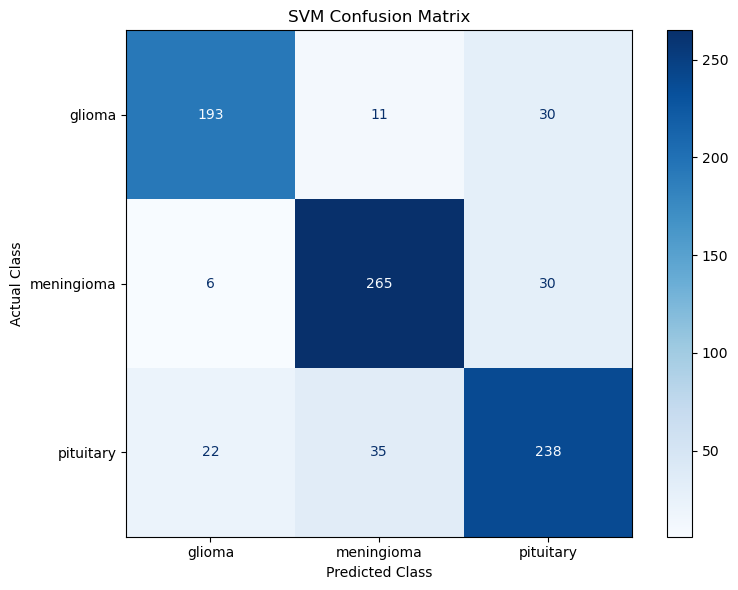


CONFUSION MATRIX COMPLETE

✓ Confusion matrix calculated
✓ Class labels verified
✓ Confusion matrix figure saved


In [28]:

# ============================================================
# CELL 7: CONFUSION MATRIX
# ============================================================
#
# Purpose:
#     Visualize how the final SVM classified each test class.
#
# Rows    = Actual classes
# Columns = Predicted classes
#
# IMPORTANT:
#     The model is NOT retrained.
#     y_test and y_pred come from the previous cells.
# ============================================================


import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)


# ============================================================
# 1. GET CLASS LABELS
# ============================================================
#
# svm_model.classes_ contains the class order used by the SVM.
#
# Example:
#
#     ['glioma', 'meningioma', 'pituitary']
# ============================================================

class_labels = svm_model.classes_


print(
    "\nClass order:"
)

print(
    class_labels
)


# ============================================================
# 2. CALCULATE CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_labels
)


# ============================================================
# 3. DISPLAY NUMERICAL CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 70)
print("CONFUSION MATRIX VALUES")
print("=" * 70)

print(
    "\nRows    = Actual"
)

print(
    "Columns = Predicted\n"
)

print(
    cm
)


# ============================================================
# 4. DISPLAY CONFUSION MATRIX AS A HEATMAP
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 6)
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)


disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)


plt.title(
    "SVM Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.tight_layout()


# ============================================================
# 5. SAVE CONFUSION MATRIX FIGURE
# ============================================================

CONFUSION_MATRIX_FILE = (
    MODEL_DIR / "svm_confusion_matrix.png"
)


plt.savefig(
    CONFUSION_MATRIX_FILE,
    dpi=300,
    bbox_inches="tight"
)


print(
    "\nConfusion matrix saved to:"
)

print(
    CONFUSION_MATRIX_FILE
)


# ============================================================
# 6. DISPLAY FIGURE
# ============================================================

plt.show()


# ============================================================
# 7. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CONFUSION MATRIX COMPLETE")
print("=" * 70)

print(
    "\n✓ Confusion matrix calculated"
)

print(
    "✓ Class labels verified"
)

print(
    "✓ Confusion matrix figure saved"
)



# roc curve

MULTICLASS ROC CURVE AND AUC

Classes:
['glioma' 'meningioma' 'pituitary']

Number of classes: 3

Binarized test label shape: (830, 3)

AUC RESULTS
glioma AUC: 0.9568
meningioma AUC: 0.9558
pituitary AUC: 0.9206

Macro-Average AUC: 0.9444

ROC curve saved to:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\svm_roc_curve.png


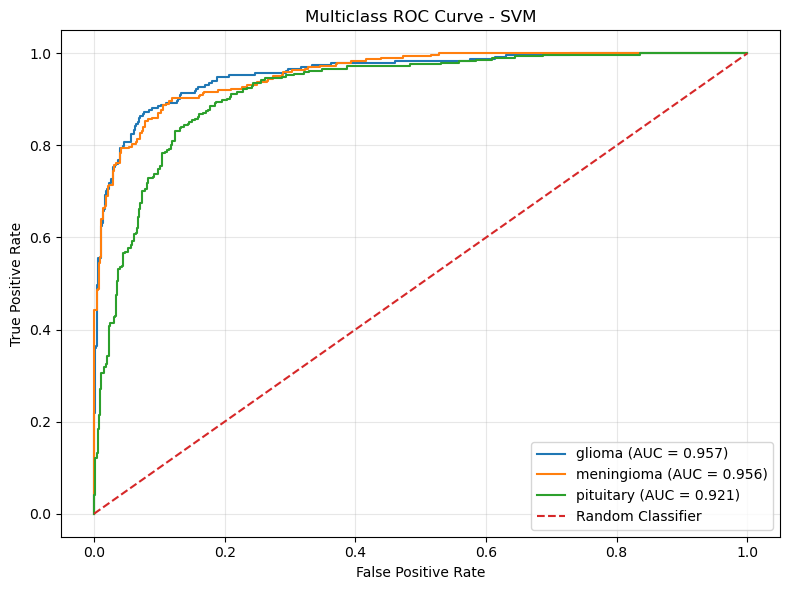


ROC/AUC EVALUATION COMPLETE
glioma: AUC = 0.9568
meningioma: AUC = 0.9558
pituitary: AUC = 0.9206

Macro-Average AUC: 0.9444

✓ One-vs-Rest ROC calculated
✓ Per-class AUC calculated
✓ Macro-Average AUC calculated
✓ ROC curve saved


In [29]:

# ============================================================
# CELL 8: MULTICLASS ROC CURVE + AUC
# ============================================================
#
# Purpose:
#     Evaluate the probability predictions produced by the
#     final SVM using ROC curves and AUC.
#
# Multiclass strategy:
#     One-vs-Rest (OvR)
#
#     For each class:
#
#         Class vs all other classes
#
# Classes:
#
#     glioma
#     meningioma
#     pituitary
#
# IMPORTANT:
#     y_proba was generated in Cell 5 using the saved SVM.
#     No model training occurs in this cell.
# ============================================================


import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score
)


print("=" * 70)
print("MULTICLASS ROC CURVE AND AUC")
print("=" * 70)


# ============================================================
# 1. GET CLASS LABELS
# ============================================================

class_labels = svm_model.classes_

number_of_classes = len(
    class_labels
)


print(
    "\nClasses:"
)

print(
    class_labels
)

print(
    "\nNumber of classes:",
    number_of_classes
)


# ============================================================
# 2. BINARY ENCODE THE TRUE LABELS
# ============================================================
#
# ROC calculation requires binary labels.
#
# Since this is a 3-class problem, label_binarize converts:
#
#     glioma
#     meningioma
#     pituitary
#
# into:
#
#     [1, 0, 0]
#     [0, 1, 0]
#     [0, 0, 1]
#
# The column order follows class_labels.
# ============================================================

y_test_binary = label_binarize(
    y_test,
    classes=class_labels
)


print(
    "\nBinarized test label shape:",
    y_test_binary.shape
)


# ============================================================
# 3. CALCULATE ROC CURVE FOR EACH CLASS
# ============================================================
#
# One-vs-Rest:
#
#     Each class is treated as the positive class while all
#     remaining classes are treated as negative.
# ============================================================

fpr = {}
tpr = {}
roc_auc = {}


for i, class_name in enumerate(class_labels):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_binary[:, i],
        y_proba[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )


# ============================================================
# 4. CALCULATE MACRO-AVERAGE AUC
# ============================================================
#
# Macro AUC gives equal importance to every class.
#
# This is useful for your multiclass problem because glioma,
# meningioma and pituitary are evaluated equally.
# ============================================================

macro_auc = roc_auc_score(
    y_test_binary,
    y_proba,
    average="macro",
    multi_class="ovr"
)


# ============================================================
# 5. DISPLAY AUC RESULTS
# ============================================================

print("\n" + "=" * 70)
print("AUC RESULTS")
print("=" * 70)


for i, class_name in enumerate(class_labels):

    print(
        f"{class_name} AUC: "
        f"{roc_auc[i]:.4f}"
    )


print(
    f"\nMacro-Average AUC: "
    f"{macro_auc:.4f}"
)


# ============================================================
# 6. PLOT ROC CURVES
# ============================================================

plt.figure(
    figsize=(8, 6)
)


for i, class_name in enumerate(class_labels):

    plt.plot(
        fpr[i],
        tpr[i],
        label=(
            f"{class_name} "
            f"(AUC = {roc_auc[i]:.3f})"
        )
    )


# ------------------------------------------------------------
# Random classifier reference line
# ------------------------------------------------------------

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)


# ============================================================
# 7. FORMAT ROC PLOT
# ============================================================

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Multiclass ROC Curve - SVM"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


# ============================================================
# 8. SAVE ROC CURVE
# ============================================================

ROC_CURVE_FILE = (
    MODEL_DIR / "svm_roc_curve.png"
)


plt.savefig(
    ROC_CURVE_FILE,
    dpi=300,
    bbox_inches="tight"
)


print(
    "\nROC curve saved to:"
)

print(
    ROC_CURVE_FILE
)


# ============================================================
# 9. DISPLAY ROC CURVE
# ============================================================

plt.show()


# ============================================================
# 10. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("ROC/AUC EVALUATION COMPLETE")
print("=" * 70)

for i, class_name in enumerate(class_labels):

    print(
        f"{class_name}: "
        f"AUC = {roc_auc[i]:.4f}"
    )


print(
    f"\nMacro-Average AUC: "
    f"{macro_auc:.4f}"
)

print(
    "\n✓ One-vs-Rest ROC calculated"
)

print(
    "✓ Per-class AUC calculated"
)

print(
    "✓ Macro-Average AUC calculated"
)

print(
    "✓ ROC curve saved"
)
